<a href="https://colab.research.google.com/github/hanashwanis/NLP-Movie-sentiment-analysis-.-HANASH/blob/main/UNDERWATER_IMAGE_SEGMENTAION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/hanashwanis/underwater-image-segmentation.git
%cd underwater-image-segmentation

Cloning into 'underwater-image-segmentation'...
remote: Enumerating objects: 20798, done.
remote: Total 20798 (delta 0), reused 0 (delta 0), pack-reused 20798 (from 1)
Receiving objects: 100% (20798/20798), 173.57 MiB | 14.92 MiB/s, done.
Resolving deltas: 100% (8133/8133), done.
Updating files: 100% (21660/21660), done.
/content/underwater-image-segmentation


In [2]:
!pip install torch torchvision transformers timm accelerate thop

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [2]:
!ls

sample_data


In [4]:
!git clone https://github.com/hanashwanis/underwater-image-segmentation.git
%cd underwater-image-segmentation

Cloning into 'underwater-image-segmentation'...
remote: Enumerating objects: 20798, done.
remote: Total 20798 (delta 0), reused 0 (delta 0), pack-reused 20798 (from 1)
Receiving objects: 100% (20798/20798), 173.57 MiB | 15.33 MiB/s, done.
Resolving deltas: 100% (8133/8133), done.
Updating files: 100% (21660/21660), done.
/content/underwater-image-segmentation


In [5]:
!ls

 check_all_classes.py   main.py       test_loader.py
 check_classes.py       metrics.py    test_metrics.py
 dataset.py	        models	      train.py
 final_results.txt      results.txt  'UNDER WATER IMAGE SEGMENTATION'


In [6]:
!find . -maxdepth 2 -type d

.
./models
./UNDER WATER IMAGE SEGMENTATION
./UNDER WATER IMAGE SEGMENTATION/masks
./UNDER WATER IMAGE SEGMENTATION/val_annotations
./UNDER WATER IMAGE SEGMENTATION/scripts
./UNDER WATER IMAGE SEGMENTATION/annotations
./UNDER WATER IMAGE SEGMENTATION/images
./UNDER WATER IMAGE SEGMENTATION/val_images
./UNDER WATER IMAGE SEGMENTATION/val_masks
./.lightning_studio
./.idea
./.git
./.git/info
./.git/branches
./.git/refs
./.git/hooks
./.git/logs
./.git/objects


In [7]:
!find "UNDER WATER IMAGE SEGMENTATION/images" -type f | wc -l
!find "UNDER WATER IMAGE SEGMENTATION/val_images" -type f | wc -l

6065
1147


In [8]:
!python check_classes.py

Mask: vid_000435_frame0000024.png
Classes: [0 1]


In [9]:
!python check_all_classes.py

Processed 0
Processed 500
Processed 1000
Processed 1500
Processed 2000
Processed 2500
Processed 3000
Processed 3500
Processed 4000
Processed 4500
Processed 5000
Processed 5500
Processed 6000
All classes: [0, 1, 2, 3]


In [10]:
!python test_loader.py

Dataset size: 6065
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([256, 256])
Mask classes: tensor([0, 3])


In [11]:
!grep -n "MODEL_NAME" train.py

64:MODEL_NAME ="attention"
65:print(f"Running model: {MODEL_NAME}")
67:if MODEL_NAME == "unet":
70:elif MODEL_NAME == "ghost":
73:elif MODEL_NAME == "half":
76:elif MODEL_NAME == "attention":
184:    f"{MODEL_NAME}.pth"


In [12]:
!ls models

attention_ghost_unetpp.py  half_unet.py       unet.py
ghost_unet.py		   test_attention.py


In [14]:
%%writefile models/segformer.py

import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation

class SegFormer(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        return outputs.logits

Writing models/segformer.py


In [15]:
!ls models

attention_ghost_unetpp.py  half_unet.py  test_attention.py
ghost_unet.py		   segformer.py  unet.py


In [16]:
from models.segformer import SegFormer

In [18]:
from google.colab import files

In [19]:
!sed -n '55,85p' train.py

    shuffle=False,
    num_workers=0
)


# ==========================
# CHOOSE MODEL
# ==========================

MODEL_NAME ="attention"
print(f"Running model: {MODEL_NAME}")

if MODEL_NAME == "unet":
    model = UNet(num_classes=4)

elif MODEL_NAME == "ghost":
    model = GhostUNet(num_classes=4)

elif MODEL_NAME == "half":
    model = HalfUNet(num_classes=4)

elif MODEL_NAME == "attention":
    model = AttentionGhostUNetPP(num_classes=4)

model = model.to(DEVICE)


# ==========================
# LOSS + OPTIMIZER
# ==========================



In [20]:
!grep -n "SegFormer" train.py

12:from models.segformer import SegFormer
80:    model = SegFormer(num_classes=4)


In [21]:
from models.segformer import SegFormer

model = SegFormer(num_classes=4)

print("SegFormer Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


SegFormer Loaded Successfully


In [22]:
!python train.py

Device: cuda
Running model: segformer
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100% 208/208 [00:00<00:00, 6393.10it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
Batch 0/380
Trac

In [23]:
!python train.py

Device: cuda
Running model: segformer
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100% 208/208 [00:00<00:00, 5527.49it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
Batch 0/380
Outp

In [24]:
!grep -n "outputs = model(images)" train.py

118:      outputs = model(images)
164:        outputs = model(images)


In [25]:
!python train.py

Device: cuda
Running model: segformer
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100% 208/208 [00:00<00:00, 6585.01it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
Batch 0/380
Outp

KeyboardInterrupt: 

In [26]:
!python train.py

Device: cuda
Running model: segformer
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100% 208/208 [00:00<00:00, 7488.09it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
Batch 0/380
Outp

In [2]:
!pwd

/content


In [4]:
!ls /content

sample_data


In [5]:
!git clone https://github.com/hanashwanis/underwater-image-segmentation.git

Cloning into 'underwater-image-segmentation'...
remote: Enumerating objects: 20798, done.
remote: Total 20798 (delta 0), reused 0 (delta 0), pack-reused 20798 (from 1)
Receiving objects: 100% (20798/20798), 173.57 MiB | 10.84 MiB/s, done.
Resolving deltas: 100% (8133/8133), done.
Updating files: 100% (21660/21660), done.


In [6]:
%cd underwater-image-segmentation
!ls

/content/underwater-image-segmentation
 check_all_classes.py   main.py       test_loader.py
 check_classes.py       metrics.py    test_metrics.py
 dataset.py	        models	      train.py
 final_results.txt      results.txt  'UNDER WATER IMAGE SEGMENTATION'


In [7]:
!grep "EPOCHS" train.py
!grep "MODEL_NAME" train.py

EPOCHS =50
for epoch in range(EPOCHS):
        f"Epoch [{epoch+1}/{EPOCHS}] "
MODEL_NAME ="attention"
print(f"Running model: {MODEL_NAME}")
if MODEL_NAME == "unet":
elif MODEL_NAME == "ghost":
elif MODEL_NAME == "half":
elif MODEL_NAME == "attention":
    f"{MODEL_NAME}.pth"


In [11]:
!ls models

attention_ghost_unetpp.py  half_unet.py  test_attention.py
ghost_unet.py		   __pycache__	 unet.py


In [12]:
%%writefile models/segformer.py

import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation


class SegFormer(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/segformer-b0-finetuned-ade-512-512",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )

    def forward(self, x):
        outputs = self.model(pixel_values=x)
        return outputs.logits

Writing models/segformer.py


In [13]:
!ls models

attention_ghost_unetpp.py  half_unet.py  segformer.py	    unet.py
ghost_unet.py		   __pycache__	 test_attention.py


In [14]:
!pip install transformers accelerate timm -q

In [15]:
from models.segformer import SegFormer

model = SegFormer(num_classes=4)

print("SegFormer loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


SegFormer loaded successfully


In [16]:
from models.segformer import SegFormer

In [17]:
!python train.py

Device: cuda
Running model: segformer
[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `150`.
Loading weights: 100% 208/208 [00:00<00:00, 6141.22it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([4, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([4])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.
Batch 0/380
Outp

In [18]:
!pip install segment-anything -q
!pip install opencv-python matplotlib -q

In [19]:
!wget -O sam_vit_b.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

--2026-06-15 17:19:22--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 65.9.168.52, 65.9.168.4, 65.9.168.81, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|65.9.168.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 375042383 (358M) [binary/octet-stream]
Saving to: ‘sam_vit_b.pth’

sam_vit_b.pth       100%[===================>] 357.67M   206MB/s    in 1.7s    

2026-06-15 17:19:24 (206 MB/s) - ‘sam_vit_b.pth’ saved [375042383/375042383]



In [20]:
import shutil

shutil.copy(
    "UNDER WATER IMAGE SEGMENTATION/val_images/vid_000002_frame0000019.jpg",
    "sam_test.jpg"
)

'sam_test.jpg'

In [21]:
import cv2
import torch
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

sam = sam_model_registry["vit_b"](
    checkpoint="sam_vit_b.pth"
)

sam.to("cuda")

mask_generator = SamAutomaticMaskGenerator(sam)

print("SAM Loaded")

SAM Loaded


In [22]:
image = cv2.imread("sam_test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image)

print("Masks Found:", len(masks))

Masks Found: 37


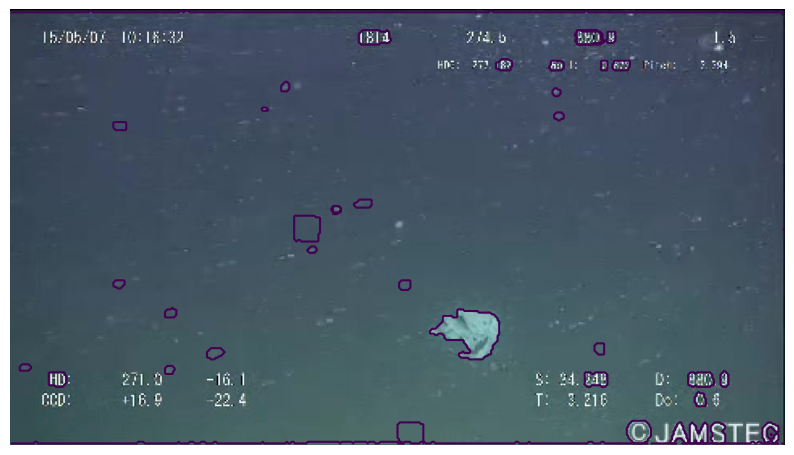

In [23]:
plt.figure(figsize=(10,10))
plt.imshow(image)

for mask in masks:
    plt.contour(mask["segmentation"])

plt.axis("off")
plt.show()

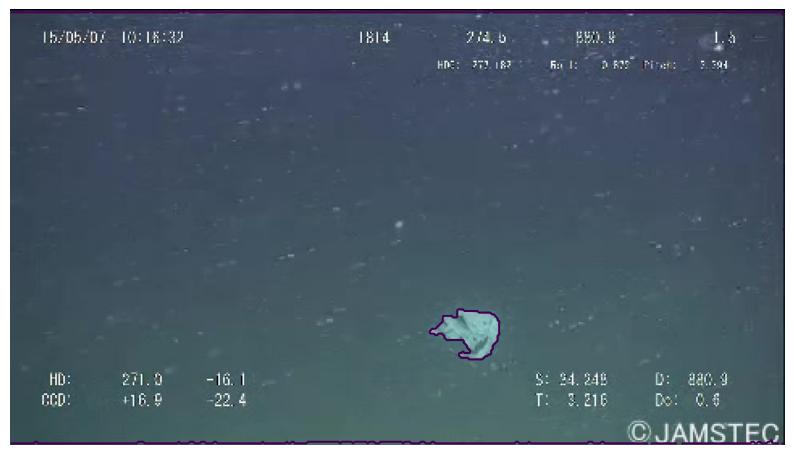

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(image)

for mask in masks:
    if mask["area"] > 500:      # keep only large objects
        plt.contour(mask["segmentation"])

plt.axis("off")
plt.show()

In [25]:
!ls *.pth

sam_vit_b.pth  segformer.pth


In [26]:
!git ls-files | grep ".pth"

In [27]:
!find /content -name "*.pth"

/content/underwater-image-segmentation/segformer.pth
/content/underwater-image-segmentation/sam_vit_b.pth


In [28]:
!find . -name "*.pth"

./segformer.pth
./sam_vit_b.pth


In [29]:
!cat final_results.txt

UNDERWATER IMAGE SEGMENTATION PROJECT

Dataset
-------
Train Images : 6065
Train Masks  : 6065

Validation Images : 1147
Validation Masks  : 1147

Classes : 4 (0,1,2,3)

Hyperparameters
---------------
Image Size : 256 x 256
Batch Size : 16
Learning Rate : 0.0001
Loss Function : CrossEntropyLoss
Optimizer : Adam
Epochs : 50

FINAL RESULTS

UNet (50 Epochs)
----------------
Loss       : 0.0191
Accuracy   : 0.9674
IoU        : 0.5338
Dice       : 0.6620
Precision  : 0.9674
Recall     : 0.9674
F1 Score   : 0.9674

GhostUNet (50 Epochs)
---------------------
Loss       : 0.0220
Accuracy   : 0.9623
IoU        : 0.4904
Dice       : 0.6198
Precision  : 0.9623
Recall     : 0.9623
F1 Score   : 0.9623

HalfUNet (50 Epochs)
--------------------
Loss       : 0.0179
Accuracy   : 0.9649
IoU        : 0.5120
Dice       : 0.6330
Precision  : 0.9649
Recall     : 0.9649
F1 Score   : 0.9649

Attention GhostUNet++ (50 Epochs)
--------------------------------
Loss       : 0.0219
Accuracy   : 0.9505
IoU     

In [31]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   train.py

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	models/segformer.py
	sam_test.jpg

no changes added to commit (use "git add" and/or "git commit -a")


In [32]:
!git add train.py
!git add models/segformer.py
!git commit -m "Added SegFormer model and training fixes"

Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@5b2c6436da12.(none)')


In [33]:
!git config --global user.email "hanash.wanis15@gmail.com"
!git config --global user.name "hanashwanis"

In [34]:
!git commit -m "Added SegFormer model and training fixes"

[main 842e3abc] Added SegFormer model and training fixes
 2 files changed, 61 insertions(+), 3 deletions(-)
 create mode 100644 models/segformer.py


In [35]:
!git push

fatal: could not read Username for 'https://github.com': No such device or address


In [36]:
!git log --oneline -1

842e3abc (HEAD -> main) Added SegFormer model and training fixes


In [37]:
!cp train.py /content/
!cp models/segformer.py /content/

In [38]:
!zip -r underwater_backup.zip train.py models

  adding: train.py (deflated 71%)
  adding: models/ (stored 0%)
  adding: models/__pycache__/ (stored 0%)
  adding: models/__pycache__/segformer.cpython-312.pyc (deflated 35%)
  adding: models/__pycache__/unet.cpython-312.pyc (deflated 61%)
  adding: models/__pycache__/half_unet.cpython-312.pyc (deflated 60%)
  adding: models/__pycache__/ghost_unet.cpython-312.pyc (deflated 59%)
  adding: models/__pycache__/attention_ghost_unetpp.cpython-312.pyc (deflated 61%)
  adding: models/half_unet.py (deflated 70%)
  adding: models/test_attention.py (deflated 26%)
  adding: models/attention_ghost_unetpp.py (deflated 73%)
  adding: models/ghost_unet.py (deflated 73%)
  adding: models/unet.py (deflated 72%)
  adding: models/segformer.py (deflated 47%)
